# DLPFC dataset (151674)

We analyzed the 151674 section of human dorsolateral prefrontal cortex (DLPFC) dataset. DLPFC with 12 tissue slices and its annotation can be obtained from the package spatialLIBD (http://research.libd.org/spatialLIBD/). 

## 1. Import packages

In [ ]:
from matplotlib import pyplot as plt
from DiverTI.utils import *
from DiverTI.genenet import obtain_genenet
from DiverTI.train import *
import torch
import scanpy as sc
import warnings
from sklearn.metrics import adjusted_rand_score 
from sklearn.metrics.cluster import normalized_mutual_info_score, homogeneity_score
os.environ['R_HOME'] = 'D:\\R\\R-4.5.0'
warnings.filterwarnings('ignore')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
seed_all(2023)
from pathlib import Path

In [2]:
import os
os.environ['R_HOME'] = 'D:\\R-4.5.0'
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector

## 2. Read data

In [ ]:
# gpu
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# path
data_root = Path(r'F:\DiverTI\realdata\DLPFC')

# sample name
name = '151674'
n_clusters = 5 if name in ['151669', '151670', '151671', '151672'] else 7

In [4]:
adata = sc.read_visium(data_root / name)
adata.var_names_make_unique()

df_meta = pd.read_csv(data_root / name / 'metadata.tsv', sep='\t')
adata.obs['layer_guess'] = df_meta['layer_guess']

In [ ]:
print(f"Number of cells: {adata.n_obs}, Number of genes: {adata.n_vars}")
print(f"Observation columns: {list(adata.obs.columns)}")
print(f"Spatial coordinates shape: {adata.obsm['spatial'].shape}")

细胞数: 3673, 基因数: 33538
数据观察值列: ['in_tissue', 'array_row', 'array_col', 'layer_guess']
空间坐标形状: (3673, 2)


## 3. Data processing, including filtering genes and identifying svgs

In [7]:
# Data preprocessing
adata.var_names_make_unique()
prefilter_genes(adata, min_cells=3)
adata, adata_raw = svg(adata, svg_method='gft_top', n_top=2000)

## 4. Construct network and GFT

Construct spot-spot network and gene co-expression network, and the graph Fourier transform was performed respectively. Obtain signal features of spots and genes.

In [8]:
# Build spotnet and genenet
obtain_spotnet(adata, knn_method='Radius', rad_cutoff=150)
gene_freq_mtx, gene_eigvecs_T, gene_eigvals = f2s_gene(adata, gene_signal=1500, c1=0.05)
obtain_genenet(adata)
spot_freq_mtx, spot_eigvecs_T, spot_eigvals = f2s_spot(adata, spot_signal=1500, middle=3, c2=0.005)
obtain_pre_spotnet(adata, adata_raw)

gene edges 23448 spots 3673


## 5. Train GAT module

In [9]:
res, lamda, emb_spot, _, attention = train_spot(adata, gene_freq_mtx, gene_eigvecs_T, spot_freq_mtx, spot_eigvecs_T,
                                                alpha=0.18, device=device, epoch_max=600)

spot*signal train


100%|██████████| 600/600 [00:54<00:00, 11.09it/s]


## 6. Downstream analysis

### Spatial cluster

In [ ]:
adata.obsm['emb'] = emb_spot
sc.pp.neighbors(adata, use_rep='emb')
cluster_num = 5 if name in ['151669', '151670', '151671', '151672'] else 7
adata = mclust_R(adata, used_obsm='emb', num_cluster=cluster_num)

obs_df = adata.obs.dropna()

NMI_score = normalized_mutual_info_score(obs_df['mclust'], obs_df['layer_guess'], average_method='max')
HS_score = homogeneity_score(obs_df['mclust'], obs_df['layer_guess'])

adata.obs['domain'] = adata.obs['mclust'].copy()
new_type = refine_label(adata, radius=30, key='domain')
adata.obs['domain'] = new_type

domain_subset = adata.obs.loc[obs_df.index, 'domain']
layer_guess_subset = obs_df['layer_guess']
ARI_score = adjusted_rand_score(domain_subset, layer_guess_subset)

print('ARI:', ARI_score)
print('NMI:', NMI_score)
print('HS:', HS_score)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
ARI: 0.6413308997092432
NMI: 0.7267384326320635
HS: 0.7267384326320635


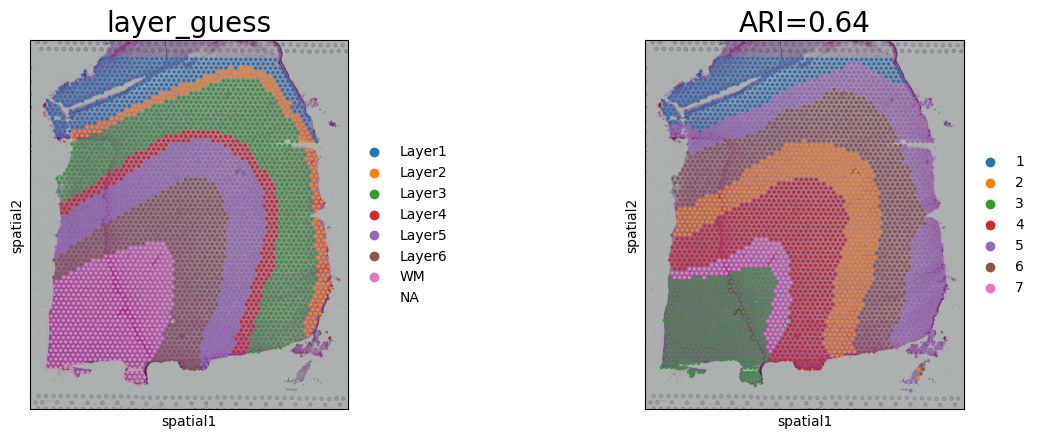

In [11]:
plt.rcParams.update({'axes.titlesize':20})
sc.pl.spatial(adata, color=['layer_guess', "domain"], title=['layer_guess', 'ARI=%.2f' % ARI_score])

In [12]:
from infer import InferExperiment

In [ ]:
adata.obsm['cascat_embedding'] = adata.obsm['emb'].copy()  
adata.obs['cascat_clusters'] = adata.obs['mclust'].copy() 
adata.obs['cascat_clusters'] = adata.obs['cascat_clusters'].astype(str)

In [14]:
print(adata.obs[['layer_guess','cascat_clusters']].groupby(['cascat_clusters','layer_guess']).size())

cascat_clusters  layer_guess
1                Layer1         330
                 Layer2          21
                 Layer3           4
                 Layer4           0
                 Layer5           0
                 Layer6           0
                 WM              10
2                Layer1           0
                 Layer2           0
                 Layer3           0
                 Layer4          34
                 Layer5         531
                 Layer6           9
                 WM               0
3                Layer1           0
                 Layer2           0
                 Layer3           0
                 Layer4           0
                 Layer5           0
                 Layer6           0
                 WM             450
4                Layer1           0
                 Layer2           0
                 Layer3           0
                 Layer4           0
                 Layer5          77
                 Layer6         580

In [ ]:
adata.obs['cascat_clusters'] = adata.obs['cascat_clusters'].astype(int)

import argparse

parser = argparse.ArgumentParser()
parser.add_argument("--root", type=int, default=3)  
parser.add_argument("--a_k", type=int, default=30)  
parser.add_argument("--ncomp", type=int, default=10)  
parser.add_argument("--threshold", type=float, default=0.3)  
parser.add_argument("--job_dir", type=str, default="./result/trajectory/DLPFC")
parser.add_argument("--seed", type=int, default=2023) 
parser.add_argument("--data_name", type=str, default="sc_data_DLPFC")
args_traj = parser.parse_args([]) 
exp = InferExperiment(args_traj, adata=adata)

using keys are cascat_clusters, cascat_embedding, cascat_connectivities, cascat_pseudotime, cascat_di_matrix
group_frac:        3      5      7      6      1      4      2
1    0.0    0.0    0.0    0.0  366.0    0.0    0.0
2    0.0    0.0    0.0    0.0    0.0    0.0  585.0
3  450.0    0.0    0.0    0.0    0.0    0.0    0.0
4    0.0    0.0    0.0    0.0    0.0  669.0    0.0
5    0.0  603.0    0.0    0.0    0.0    0.0    0.0
6    0.0    0.0    0.0  823.0    0.0    0.0    0.0
7    0.0    0.0  177.0    0.0    0.0    0.0    0.0
No start cell id, use truth label in cluster to find start cell
Root is 3, Start cell idx is 0
Finish load Infer params
Finish initialize tree params


In [ ]:
print("Type of cluster labels (cascat_clusters):", adata.obs['cascat_clusters'].dtype)
print("All unique values of cluster labels:", sorted(adata.obs['cascat_clusters'].unique()))
print("Distribution of cluster labels:")
print(adata.obs['cascat_clusters'].value_counts())

聚类标签（cascat_clusters）的类型： int32
聚类标签的所有取值： [1, 2, 3, 4, 5, 6, 7]
聚类标签分布：
cascat_clusters
6    823
4    669
5    603
2    585
3    450
1    366
7    177
Name: count, dtype: int64


In [ ]:
start_cell_idx = adata.uns['start_cell_idx']  
start_cell_id = adata.obs_names[start_cell_idx] 
adata.uns['start_id'] = start_cell_id
print("已添加start_id：", adata.uns['start_id'])
exp.infer()

已添加start_id： AAACAAGTATCTCCCA-1
树节点: ['3', '5', '7', '6', '1', '4', '2']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/DLPFC/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 7 节点, 21 边
最小生成树构建完成: 6 边
有向树构建完成: 6 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 7 节点, 6 边
开始基于DI的树构建
树节点: ['3', '5', '7', '6', '1', '4', '2']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/DLPFC/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 7 节点, 21 边
最小生成树构建完成: 6 边
有向树构建完成: 6 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 7 节点, 6 边
✅ 有向树邻接矩阵生成完成，已存入adata.uns['cascat_directed_tree_conn']
生成的邻接矩阵：
     1    2    3    4    5    6    7
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  1.0
4  1.0  1.0  0.0  0.0  0.0  0.0  0.0
5  0.0  0.0  0.0  0.0  0.0  0.0  0.0
6  0.0  0.0  0.0  0.0  1.0  0.0  0.0
7  0.0  0.0  0.0  1.0  0.0  0.0  0.0
基于DI的树构建完成
Number of inf in pseudotime is 0
No ground truth for evaluation


(None, None, None, None)

In [18]:
from models.model_utils import DIPlot

从DI矩阵构建的连接矩阵:
     1    2    3    4    5    6    7
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  1.0
4  1.0  1.0  0.0  0.0  0.0  0.0  0.0
5  0.0  0.0  0.0  0.0  0.0  0.0  0.0
6  0.0  0.0  0.0  0.0  1.0  0.0  0.0
7  0.0  0.0  0.0  1.0  0.0  0.0  0.0
非零连接数: 6


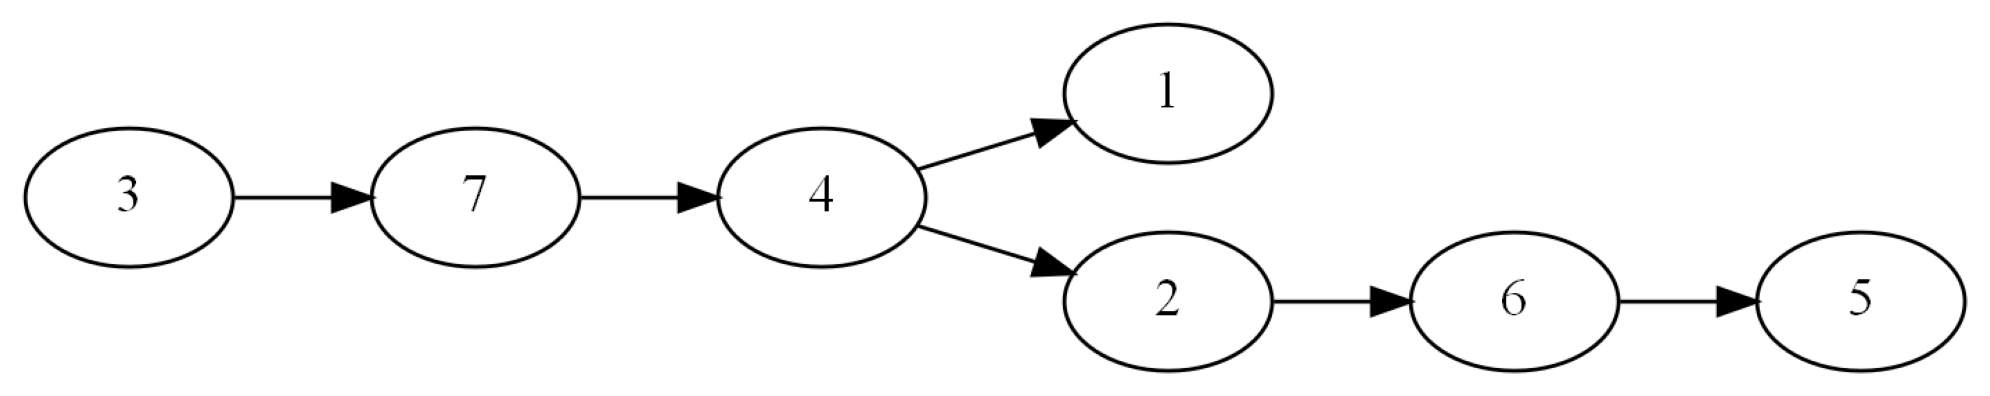

In [ ]:
from models.model_utils import *
adata.obs['cluster'] = adata.obs['cascat_clusters'].copy()

pseudo_key = 'cascat_pseudotime'
obj = DIPlot(adata
             , start_cell_idx=adata.uns['start_id'],
              root=adata.uns['root'], group_frac=adata.uns['group_frac'], save_path='./result',
              pseudo_key='cascat_pseudotime', di_key='cascat_directed_tree_conn', predict_key='cascat_clusters',
              emb_key='cascat_embedding')
obj.plot_trajectory_tree()

反转后各聚类的伪时间分布:
                 count      mean       std       min       25%       50%  \
cascat_clusters                                                            
1                366.0  0.394029  0.045418  0.291647  0.358177  0.393333   
2                585.0  0.742055  0.051483  0.469129  0.708383  0.749154   
3                450.0  0.108382  0.041568  0.000000  0.079865  0.109253   
4                669.0  0.563729  0.071786  0.190700  0.510518  0.576328   
5                603.0  0.903023  0.041352  0.781061  0.873208  0.911623   
6                823.0  0.890969  0.042528  0.472360  0.865848  0.894024   
7                177.0  0.347887  0.053165  0.085008  0.330471  0.354878   

                      75%       max  
cascat_clusters                      
1                0.428455  0.520467  
2                0.780604  0.837283  
3                0.135011  0.215741  
4                0.615961  0.704991  
5                0.932539  0.981142  
6                0.918538  1.000000

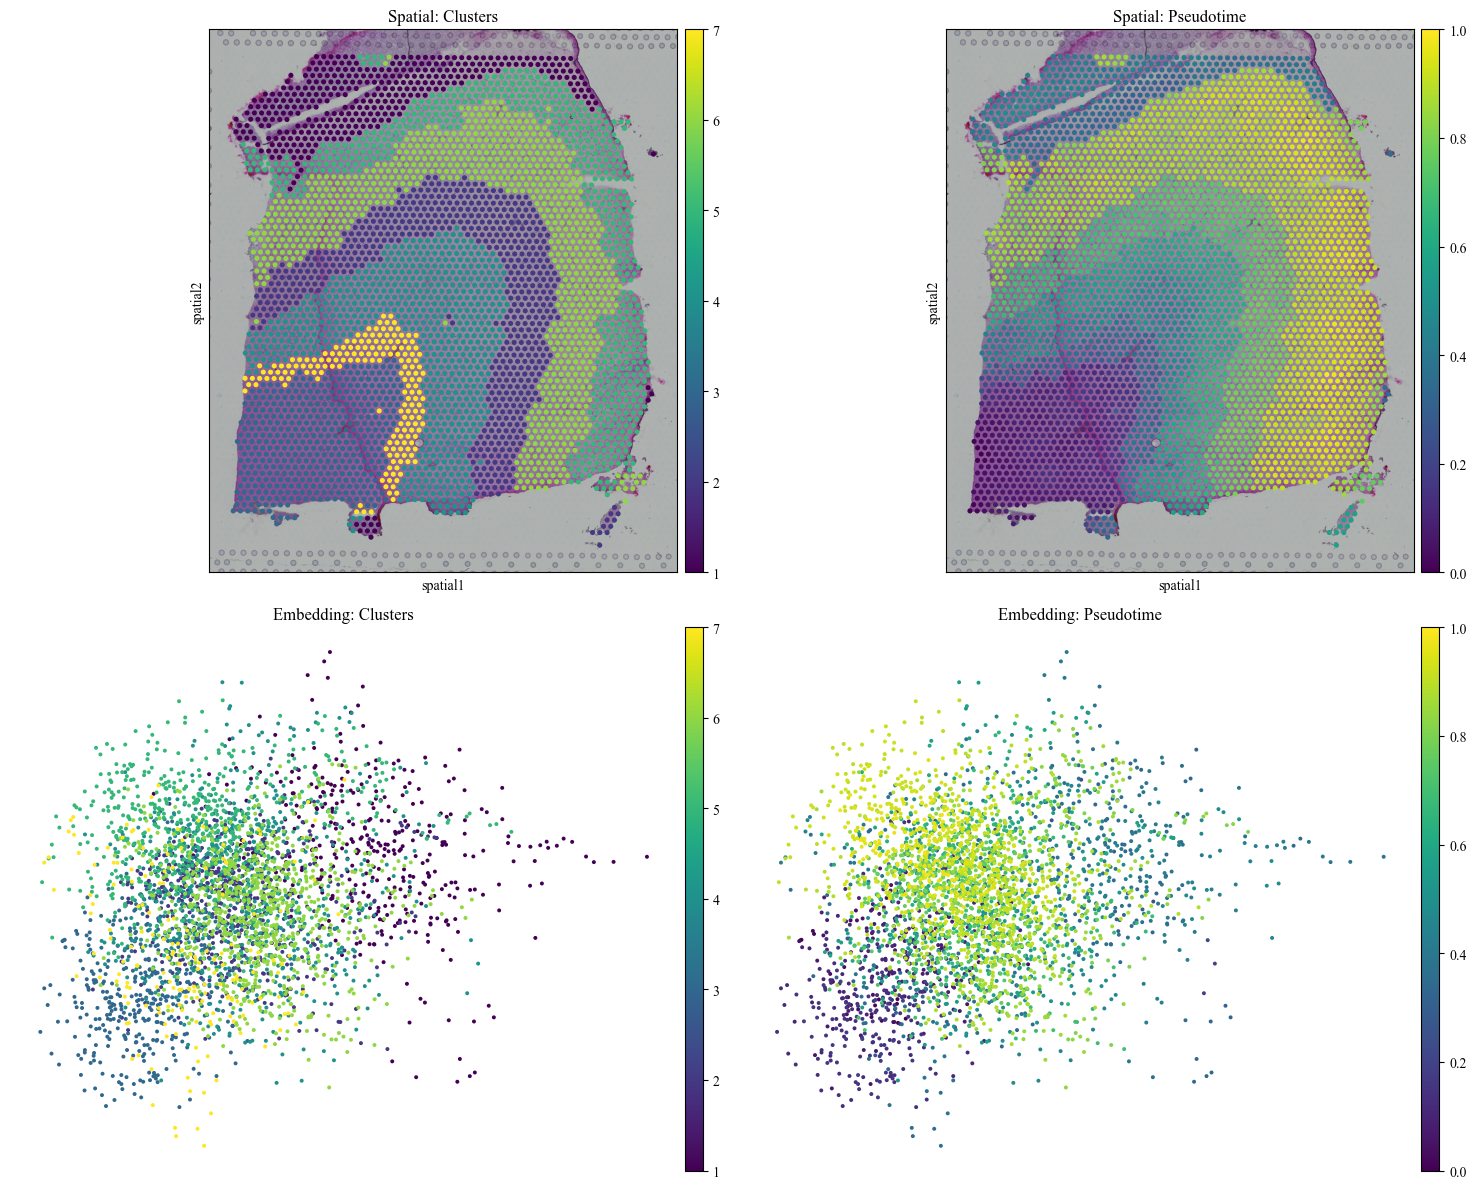

In [ ]:
adata.obs['cascat_pseudotime'] = 1 - adata.obs['cascat_pseudotime']
print(adata.obs.groupby('cascat_clusters')['cascat_pseudotime'].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sc.pl.spatial(adata, color='cascat_clusters', ax=axes[0, 0], show=False, title='Spatial: Clusters')
axes[0, 0].set_title('Spatial: Clusters', fontsize=12)

sc.pl.spatial(adata, color='cascat_pseudotime', ax=axes[0, 1], show=False, title='Spatial: Pseudotime', cmap='viridis')
axes[0, 1].set_title('Spatial: Pseudotime', fontsize=12)

sc.pl.embedding(adata, basis='cascat_embedding', color='cascat_clusters', 
                ax=axes[1, 0], show=False, title='Embedding: Clusters', frameon=False)
axes[1, 0].set_title('Embedding: Clusters', fontsize=12)

sc.pl.embedding(adata, basis='cascat_embedding', color='cascat_pseudotime', 
                ax=axes[1, 1], show=False, title='Embedding: Pseudotime', frameon=False, cmap='viridis')
axes[1, 1].set_title('Embedding: Pseudotime', fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
exp.infer()

树节点: ['3', '5', '7', '6', '1', '4', '2']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/DLPFC/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 7 节点, 21 边
最小生成树构建完成: 6 边
有向树构建完成: 6 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 7 节点, 6 边
开始基于DI的树构建
树节点: ['3', '5', '7', '6', '1', '4', '2']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/DLPFC/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 7 节点, 21 边
最小生成树构建完成: 6 边
有向树构建完成: 6 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 7 节点, 6 边
✅ 有向树邻接矩阵生成完成，已存入adata.uns['cascat_directed_tree_conn']
生成的邻接矩阵：
     1    2    3    4    5    6    7
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  1.0
4  1.0  1.0  0.0  0.0  0.0  0.0  0.0
5  0.0  0.0  0.0  0.0  0.0  0.0  0.0
6  0.0  0.0  0.0  0.0  1.0  0.0  0.0
7  0.0  0.0  0.0  1.0  0.0  0.0  0.0
基于DI的树构建完成
Number of inf in pseudotime is 0
No ground truth for evaluation


(None, None, None, None)

In [23]:
conn = adata.uns["cascat_directed_tree_conn"].copy()
conn.index = conn.index.astype(str)
conn.columns = conn.columns.astype(str)

print(conn)

     1    2    3    4    5    6    7
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  1.0
4  1.0  1.0  0.0  0.0  0.0  0.0  0.0
5  0.0  0.0  0.0  0.0  0.0  0.0  0.0
6  0.0  0.0  0.0  0.0  1.0  0.0  0.0
7  0.0  0.0  0.0  1.0  0.0  0.0  0.0


In [24]:
sc.pp.calculate_qc_metrics(adata, inplace=True)
adata.obs.groupby("cascat_clusters")[["total_counts", "n_genes_by_counts"]].mean()

,total_counts,n_genes_by_counts
cascat_clusters,,
1,841.741722,1631.986339
2,995.808676,1723.377778
3,967.658070,1724.968889
4,949.666467,1681.512706
5,982.533974,1741.844113
6,978.263981,1719.375456
7,963.913022,1709.446328


In [25]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

adata.obs.groupby("cascat_clusters")[["pct_counts_mt"]].mean()

,pct_counts_mt
cascat_clusters,
1,5.508335
2,4.561074
3,4.337329
4,4.653017
5,4.748956
6,4.820149
7,4.617433


In [ ]:
import numpy as np
import pandas as pd

def get_cluster_mean_expression(adata, genes, cluster_key="cascat_clusters"):
    """
    Calculate the mean expression of each cluster for a given set of genes.
    Returns: DataFrame(index=cluster, columns=genes)
    """
    genes = [g for g in genes if g in adata.var_names]
    if len(genes) == 0:
        raise ValueError("None of the given marker genes were found in adata.var_names.")

    X = adata[:, genes].X
    try:
        X = X.toarray()
    except Exception:
        X = np.asarray(X)

    expr_df = pd.DataFrame(X, index=adata.obs_names, columns=genes)
    expr_df["cluster"] = adata.obs[cluster_key].astype(str).values

    cluster_expr = expr_df.groupby("cluster")[genes].mean()
    return cluster_expr


def compute_marker_similarity(cluster_expr, low_c, candidate_c):
    """
    Marker continuity: the more similar, the higher the score.
    Here we convert Euclidean distance into a similarity score.
    """
    v1 = cluster_expr.loc[str(low_c)].values
    v2 = cluster_expr.loc[str(candidate_c)].values
    dist = np.linalg.norm(v1 - v2)
    sim = 1.0 / (1.0 + dist)
    return sim


def compute_spatial_boundary_similarity(adata, low_c, candidate_c, cluster_key="cascat_clusters", spatial_key="spatial"):
    """
    Spatial adjacency: the closer the boundaries between two clusters, the higher the similarity.
    Here we convert the closest-point distance into a similarity score.
    """
    xy = adata.obsm[spatial_key]
    labs = adata.obs[cluster_key].astype(str).values

    pts1 = xy[labs == str(low_c)]
    pts2 = xy[labs == str(candidate_c)]

    if len(pts1) == 0 or len(pts2) == 0:
        return 0.0

    dists = ((pts1[:, None, :] - pts2[None, :, :]) ** 2).sum(axis=2)
    min_dist = np.sqrt(dists.min())
    sim = 1.0 / (1.0 + min_dist)
    return sim

In [ ]:
marker_genes = [
    "RELN", "CUX1", "CUX2",     
    "RORB",                     
    "BCL11B", "FEZF2", "FOXP2", 
    "SATB2", "TLE4"
]

In [28]:
[g for g in marker_genes if g in adata.var_names]

['RELN', 'CUX2', 'RORB', 'SATB2', 'TLE4']

In [ ]:
conn = adata.uns["cascat_directed_tree_conn"].copy()
conn.index = conn.index.astype(str)
conn.columns = conn.columns.astype(str)

qc = adata.obs.groupby("cascat_clusters")[["pct_counts_mt", "total_counts", "n_genes_by_counts"]].mean().copy()
qc["bad_score"] = (
    (qc["pct_counts_mt"] - qc["pct_counts_mt"].mean()) / qc["pct_counts_mt"].std()
    - (qc["total_counts"] - qc["total_counts"].mean()) / qc["total_counts"].std()
    - (qc["n_genes_by_counts"] - qc["n_genes_by_counts"].mean()) / qc["n_genes_by_counts"].std()
)
low_quality_clusters = qc.sort_values("bad_score", ascending=False).head(1).index.astype(str).tolist()

low_c = low_quality_clusters[0]
print("Automatically identified low-quality cluster:", low_c)

conn_trim = conn.copy()
conn_trim.loc[low_c, :] = 0
conn_trim.loc[:, low_c] = 0

main_clusters = [c for c in conn_trim.index if c != low_c]

cluster_expr = get_cluster_mean_expression(
    adata,
    genes=marker_genes,
    cluster_key="cascat_clusters"
)

w_marker = 0.6
w_spatial = 0.4

scores = []
for c in main_clusters:
    marker_sim = compute_marker_similarity(cluster_expr, low_c, c)
    spatial_sim = compute_spatial_boundary_similarity(
        adata,
        low_c,
        c,
        cluster_key="cascat_clusters",
        spatial_key="spatial"
    )
    final_score = w_marker * marker_sim + w_spatial * spatial_sim
    scores.append((c, marker_sim, spatial_sim, final_score))

score_df = pd.DataFrame(scores, columns=["candidate", "marker_sim", "spatial_sim", "final_score"])
score_df = score_df.sort_values("final_score", ascending=False).reset_index(drop=True)

print(score_df)

best_parent = score_df.loc[0, "candidate"]
print(f"Low-quality cluster {low_c} automatically merged into {best_parent}")

conn_new = conn_trim.copy()
conn_new.loc[str(best_parent), str(low_c)] = 1

adata.uns["cascat_directed_tree_conn"] = conn_new
adata.uns["cascat_connectivities"] = conn_new.copy()

print(conn_new)

自动识别的低质量簇: 1
  candidate  marker_sim  spatial_sim  final_score
0         5    0.817931     0.007246     0.493657
1         4    0.801546     0.007246     0.483826
2         6    0.792948     0.007246     0.478668
3         3    0.784303     0.004149     0.472242
4         7    0.777773     0.007198     0.469543
5         2    0.765440     0.000789     0.459579
低质量簇 1 自动挂接到 5
更新后的树：
     1    2    3    4    5    6    7
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  1.0
4  0.0  1.0  0.0  0.0  0.0  0.0  0.0
5  1.0  0.0  0.0  0.0  0.0  0.0  0.0
6  0.0  0.0  0.0  0.0  1.0  0.0  0.0
7  0.0  0.0  0.0  1.0  0.0  0.0  0.0


In [30]:
exp.compute_pseudotime(reverse_penalty=8.0, intra_cluster_connect=True)

Number of inf in pseudotime is 0


反转后各聚类的伪时间分布:
                 count      mean       std       min       25%       50%  \
cascat_clusters                                                            
1                366.0  0.755874  0.050933  0.588326  0.717671  0.761756   
2                585.0  0.742055  0.051483  0.469129  0.708383  0.749154   
3                450.0  0.108382  0.041568  0.000000  0.079865  0.109253   
4                669.0  0.563729  0.071786  0.190700  0.510518  0.576328   
5                603.0  0.903023  0.041352  0.781061  0.873208  0.911623   
6                823.0  0.890969  0.042528  0.472360  0.865848  0.894024   
7                177.0  0.347887  0.053165  0.085008  0.330471  0.354878   

                      75%       max  
cascat_clusters                      
1                0.795088  0.856050  
2                0.780604  0.837283  
3                0.135011  0.215741  
4                0.615961  0.704991  
5                0.932539  0.981142  
6                0.918538  1.000000

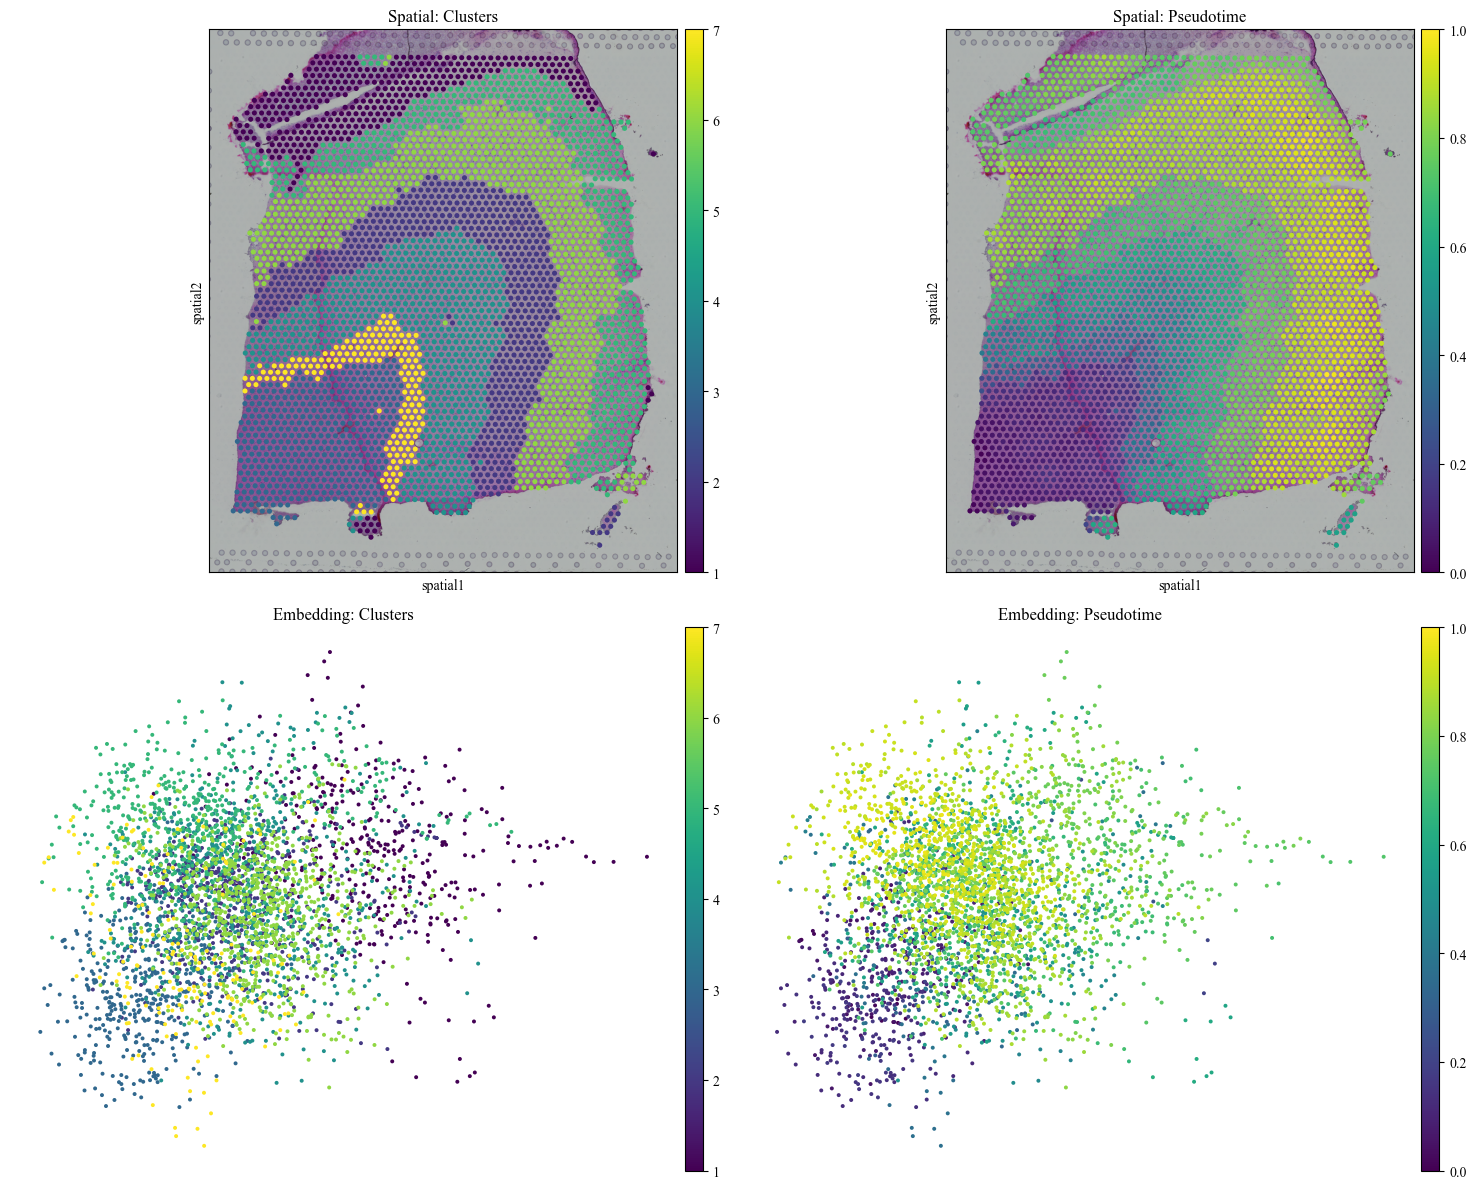

In [ ]:
adata.obs['cascat_pseudotime'] = 1 - adata.obs['cascat_pseudotime']

print(adata.obs.groupby('cascat_clusters')['cascat_pseudotime'].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sc.pl.spatial(adata, color='cascat_clusters', ax=axes[0, 0], show=False, title='Spatial: Clusters')
axes[0, 0].set_title('Spatial: Clusters', fontsize=12)

sc.pl.spatial(adata, color='cascat_pseudotime', ax=axes[0, 1], show=False, title='Spatial: Pseudotime', cmap='viridis')
axes[0, 1].set_title('Spatial: Pseudotime', fontsize=12)

sc.pl.embedding(adata, basis='cascat_embedding', color='cascat_clusters', 
                ax=axes[1, 0], show=False, title='Embedding: Clusters', frameon=False)
axes[1, 0].set_title('Embedding: Clusters', fontsize=12)

sc.pl.embedding(adata, basis='cascat_embedding', color='cascat_pseudotime', 
                ax=axes[1, 1], show=False, title='Embedding: Pseudotime', frameon=False, cmap='viridis')
axes[1, 1].set_title('Embedding: Pseudotime', fontsize=12)

plt.tight_layout()
plt.show()

从DI矩阵构建的连接矩阵:
     1    2    3    4    5    6    7
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  1.0
4  0.0  1.0  0.0  0.0  0.0  0.0  0.0
5  1.0  0.0  0.0  0.0  0.0  0.0  0.0
6  0.0  0.0  0.0  0.0  1.0  0.0  0.0
7  0.0  0.0  0.0  1.0  0.0  0.0  0.0
非零连接数: 6


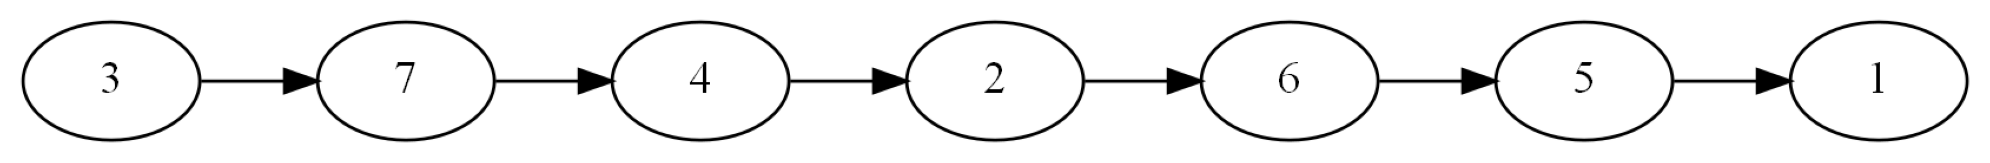

In [ ]:
from models.model_utils import *

adata.obs['cluster'] = adata.obs['cascat_clusters'].copy()

pseudo_key = 'cascat_pseudotime'
obj = DIPlot(adata
             , start_cell_idx=adata.uns['start_id'],
              root=adata.uns['root'], group_frac=adata.uns['group_frac'], save_path='./result',
              pseudo_key='cascat_pseudotime', di_key='cascat_directed_tree_conn', predict_key='cascat_clusters',
              emb_key='cascat_embedding')
obj.plot_trajectory_tree()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import scanpy as sc


def edges_from_cluster_adjacency(adata, key="cascat_directed_tree_conn"):
    M = adata.uns[key]
    if isinstance(M, pd.DataFrame):
        A = M.copy()
    else:
        A = pd.DataFrame(M)

    A.index = A.index.astype(str)
    A.columns = A.columns.astype(str)

    edges = []
    for s in A.index:
        for t in A.columns:
            if float(A.loc[s, t]) > 0:
                edges.append((str(s), str(t)))
    return edges


def get_linear_order_from_edges(edges):
    sources = [s for s, t in edges]
    targets = [t for s, t in edges]

    start_candidates = [s for s in sources if s not in targets]
    if len(start_candidates) != 1:
        raise ValueError(f"Not a single-chain structure, start candidates are: {start_candidates}")

    start = start_candidates[0]
    next_map = {s: t for s, t in edges}

    order = [start]
    while order[-1] in next_map:
        order.append(next_map[order[-1]])
    return order


def compute_cluster_medoids(adata, cluster_key="domain", spatial_key="spatial"):
    xy = adata.obsm[spatial_key]
    labs = adata.obs[cluster_key].astype(str).values

    centers = {}
    for c in np.unique(labs):
        pts = xy[labs == c]
        mean_pt = pts.mean(axis=0)
        d = ((pts - mean_pt) ** 2).sum(axis=1)
        medoid = pts[np.argmin(d)]
        centers[str(c)] = medoid
    return centers


def draw_backbone_trajectory(ax, centers, order, lw=3.2, arrow_scale=26, color="black"):
    ax.set_autoscale_on(False)

    for i in range(len(order) - 1):
        a = order[i]
        b = order[i + 1]
        if a not in centers or b not in centers:
            continue

        p1 = centers[a]
        p2 = centers[b]

        arrow = FancyArrowPatch(
            (p1[0], p1[1]),
            (p2[0], p2[1]),
            arrowstyle="-|>",
            mutation_scale=arrow_scale,
            lw=lw,
            color=color,
            alpha=0.95,
            connectionstyle="arc3,rad=0.0",
            zorder=50
        )
        ax.add_patch(arrow)


def annotate_cluster_order(ax, centers, order, fontsize=9):
    ax.set_autoscale_on(False)

    for i, c in enumerate(order, start=1):
        if c not in centers:
            continue
        x, y = centers[c]
        ax.text(
            x, y,
            f"{i}:{c}",
            ha="center",
            va="center",
            fontsize=fontsize,
            weight="bold",
            color="black",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="black", alpha=0.85),
            zorder=60,
            clip_on=True
        )


def plot_layer_and_domain_with_backbone(
    adata,
    truth_key="layer_guess",
    cluster_key="domain",
    edge_key="cascat_directed_tree_conn",
    point_size=20,
):
    edges = edges_from_cluster_adjacency(adata, key=edge_key)
    order = get_linear_order_from_edges(edges)
    centers = compute_cluster_medoids(adata, cluster_key=cluster_key, spatial_key="spatial")

    print("Restored backbone order:", " → ".join(order))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=180)
    sc.pl.embedding(
        adata,
        basis="spatial",
        color=truth_key,
        ax=axes[0],
        show=False,
        title="True annotation",
        frameon=True,
        size=point_size
    )

    sc.pl.embedding(
        adata,
        basis="spatial",
        color=cluster_key,
        ax=axes[1],
        show=False,
        title="CASCAT backbone trajectory",
        frameon=True,
        size=point_size
    )

    xlim = axes[1].get_xlim()
    ylim = axes[1].get_ylim()

    draw_backbone_trajectory(
        axes[1],
        centers=centers,
        order=order,
        lw=3.2,
        arrow_scale=26,
        color="black"
    )

    annotate_cluster_order(
        axes[1],
        centers=centers,
        order=order,
        fontsize=9
    )

    axes[1].set_xlim(xlim)
    axes[1].set_ylim(ylim)

    axes[0].invert_yaxis()
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

恢复得到的主干顺序: 3 → 7 → 4 → 2 → 6 → 5 → 1


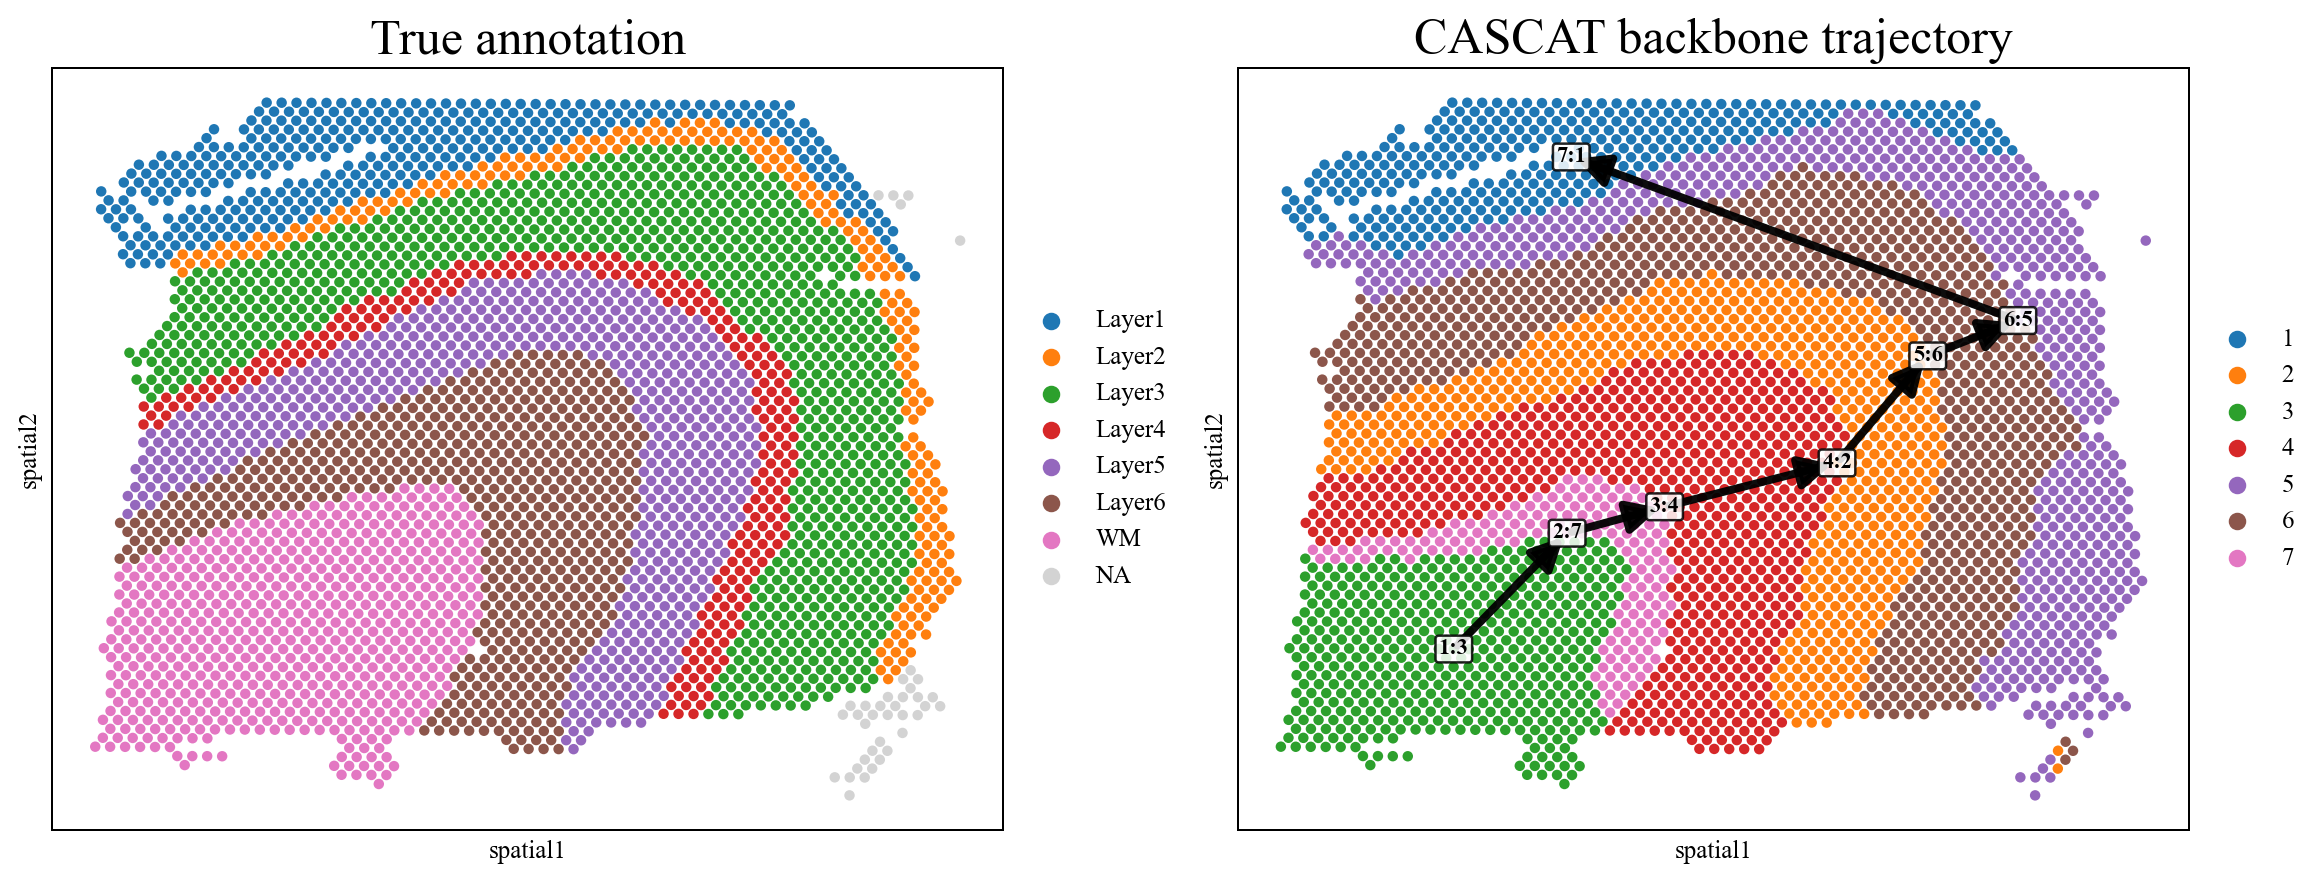

In [34]:
plot_layer_and_domain_with_backbone(
    adata,
    truth_key="layer_guess",
    cluster_key="domain",   # 或 "cascat_clusters"
    edge_key="cascat_directed_tree_conn",
    point_size=70
)